<div style="font-family:monospace; font-size:15px; line-height:1.5; border-top: 1px solid black; border-bottom: 1px solid black; padding: 10px; text-align: center;">
    <strong>AUTOENCODER -  DIMENSIONALITY REDUCTION</strong><br>
    <strong></strong> SIVA VIKNESH<br>
    <strong></strong> siva.viknesh@sci.utah.edu / sivaviknesh14@gmail.com<br>
    <strong></strong> SCIENTIFIC COMPUTING & IMAGING INSTITUTE, UNIVERSITY OF UTAH, SALT LAKE CITY, UTAH, USA<br>
</div>

In [1]:
# ****** IMPORTING THE NECESSARY LIBRARIES
import os
import torch
import math
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.nn.parameter import Parameter
import vtk
from vtk.util.numpy_support import vtk_to_numpy 
import matplotlib.pyplot as plt

In [2]:
processor = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("AVAILABLE PROCESSOR:", processor)

AVAILABLE PROCESSOR: cuda


In [3]:
# Set random seed for reproducibility
seed = 15
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

<div style="text-align: center; font-weight: bold; font-size: 1em;">
    DEFINING THE PARAMETERS
</div>

In [4]:
# ***** PARAMETERS FOR THE NEURAL NETWORK
x_dim        = 256
y_dim        = 256

# ***** HYPERPARAMETERS FOR THE NEURAL NETWORK
inp_neuron   = x_dim*y_dim  #Nfile - 1
epochs       = 2000
batchsize    = 256 

learn_rate   = 1e-2
step_epoch   = 100
decay_rate   = 0.50

# ***** FILENAMES TO READ & WRITE THE DATA
mesh         = "Grid_256_0.vtk"
data_file    = "Grid_256_"
Nfile        = 1000                                 # NO. OF TIME INSTANTS

# ***** LOCATION TO READ AND WRITE THE DATA
pwd          = os.getcwd()
os.chdir("../../../")
directory    = os.getcwd()
path         = directory + "/Flow_Data/"
mesh         = path + mesh
data_file    = path + data_file

# ***** NORMALISATION OF FLOW VARIABLES
xscale       = 10.0
yscale       = 5.0
vort_max     = 4.4

<div style="text-align: center; font-weight: bold; font-size: 1em;">
    READING THE DATA FILES
</div>


In [5]:
''' ***************************************** MESH FILE ****************************************************** '''
print ("*"*85)
print ('READING THE MESH FILE: ', mesh[len(directory)+1:])
reader = vtk.vtkStructuredPointsReader()
reader.SetFileName(mesh)
reader.Update()
data = reader.GetOutput()
n_points = data.GetNumberOfPoints()
print ('NO. OF GRID POINTS IN THE MESH:', n_points)
x_vtk_mesh = np.zeros((n_points,1))
y_vtk_mesh = np.zeros((n_points,1))
for i in range(n_points):
    pt_iso  =  data.GetPoint(i)
    x_vtk_mesh[i] = pt_iso[0] 
    y_vtk_mesh[i] = pt_iso[1]
    
x  = np.reshape(x_vtk_mesh, (x_dim, y_dim))/xscale 
y  = np.reshape(y_vtk_mesh, (x_dim, y_dim))/yscale

print ("SHAPE OF X:",   x.shape)
print ("SHAPE OF Y:",   y.shape)

print ("*"*85)

''' *************************************** FLOW FIELD FILE *************************************************** '''
fieldname1  = 'u_vel'                                                      # FIELD NAME FOR VTK FILES
fieldname2  = 'v_vel'
fieldname3  = 'vort_z'

#u_vel   = np.zeros((Nfile, x_dim, y_dim))
#v_vel   = np.zeros((Nfile, x_dim, y_dim))
vort    = np.zeros((Nfile, x_dim, y_dim))

for i in range(Nfile):
    file_name = data_file + str(i) + ".vtk"
    print ('READING THE DATA FILE: ', file_name[len(directory)+1:])
    reader = vtk.vtkStructuredPointsReader()
    reader.SetFileName(file_name)
    reader.Update()
    data = reader.GetOutput()
    #pointData1 = data.GetPointData().GetArray(fieldname1)
    #pointData2 = data.GetPointData().GetArray(fieldname2)    
    pointData3 = data.GetPointData().GetArray(fieldname3)    
    #u_vel   [i, :, :] = np.reshape(vtk_to_numpy(pointData1), (x_dim, y_dim))
    #v_vel   [i, :, :] = np.reshape(vtk_to_numpy(pointData2), (x_dim, y_dim))
    vort    [i, :, :] = np.reshape(vtk_to_numpy(pointData3), (x_dim, y_dim))
    
    print ("*"*85)
vort = vort / vort_max

*************************************************************************************
READING THE MESH FILE:  Flow_Data/Grid_256_0.vtk
NO. OF GRID POINTS IN THE MESH: 65536
SHAPE OF X: (256, 256)
SHAPE OF Y: (256, 256)
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_0.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_1.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_2.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_3.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_4.vtk
*************************************************************************************
READING THE DATA FIL

*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_89.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_90.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_91.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_92.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_93.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_94.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_95.vtk
************************************************

*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_155.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_156.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_157.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_158.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_159.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_160.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_161.vtk
*****************************************

*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_333.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_334.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_335.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_336.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_337.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_338.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_339.vtk
*****************************************

*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_399.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_400.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_401.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_402.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_403.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_404.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_405.vtk
*****************************************

*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_579.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_580.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_581.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_582.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_583.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_584.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_585.vtk
*****************************************

*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_804.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_805.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_806.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_807.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_808.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_809.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_810.vtk
*****************************************

*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_867.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_868.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_869.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_870.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_871.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_872.vtk
*************************************************************************************
READING THE DATA FILE:  Flow_Data/Grid_256_873.vtk
*****************************************

<div style="text-align: center; font-weight: bold; font-size: 1em;">
    DEFINING THE CLASS FUNCTIONS - AE
</div>


In [6]:
class ENCODER (nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(inp_neuron, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 16)
        )    
    def forward(self,x):
        output = self.encoder(x)
        return output
    
class DECODER (nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2048),
            nn.ReLU(),
            nn.Linear(2048, inp_neuron)
        ) 
    
    def forward(self, x):
        output = self.decoder(x)
        return output
    
def init_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [7]:
# FUNCTION MAPPING DATA
vort_input   = torch.Tensor(vort).to(processor).reshape(vort.shape[0], -1)
vort_output  = torch.Tensor(vort).to(processor).reshape(vort.shape[0], -1)

# SORTING THE TRAINING DATA
shape         = vort_input.size()
total_samples = shape[0]

train_size    = int(0.8 * total_samples)
test_size     = total_samples - train_size

dataset               = TensorDataset(vort_input, vort_output)
vort_train, vort_test = random_split(dataset, [train_size, test_size], generator=torch.manual_seed(seed))

train_loader   = DataLoader(vort_train, batch_size=batchsize, shuffle=True)
test_loader    = DataLoader(vort_test,  batch_size=10,        shuffle=False)
plot_loader    = DataLoader(dataset,    batch_size=batchsize, shuffle=False)
    
encoder_model  = ENCODER ().to(processor)
decoder_model  = DECODER ().to(processor)

encoder_optim  = optim.Adam(encoder_model.parameters(), lr=learn_rate, betas = (0.9,0.99), eps = 10**-15)
decoder_optim  = optim.Adam(decoder_model.parameters(), lr=learn_rate, betas = (0.9,0.99), eps = 10**-15)

encoder_sched  = optim.lr_scheduler.StepLR(encoder_optim, step_size=step_epoch, gamma=decay_rate)
decoder_sched  = optim.lr_scheduler.StepLR(decoder_optim, step_size=step_epoch, gamma=decay_rate)

encoder_params = count_params(encoder_model)
decoder_params = count_params(decoder_model)

print(f"Encoder Parameters: {encoder_params}")
print(f"Decoder Parameters: {decoder_params}")


Encoder Parameters: 136910480
Decoder Parameters: 136976000


<div style="text-align: center; font-weight: bold; font-size: 1em;">
    AE - TRAINING DATA
</div>


In [8]:
Loss_Data   = torch.empty(size=(epochs, 1))
loss_func   = nn.MSELoss()

for epoch in range (epochs):
    total_loss = 0.0
    for batch_idx, (w_in, w_out) in enumerate(train_loader):
        encoder_output = encoder_model (w_in)
        decoder_output = decoder_model (encoder_output)
        batch_loss     = loss_func   (decoder_output, w_out)

        encoder_optim.zero_grad()
        decoder_optim.zero_grad()
        batch_loss.backward()

        with torch.no_grad():
            encoder_optim.step()
            decoder_optim.step()

        total_loss += batch_loss.detach()  

    N = batch_idx + 1
    Loss_Data   [epoch] = total_loss/N
        
    print('TOTAL AVERAGE LOSS, [EPOCH =', epoch,']')
    print('LOSS          :', Loss_Data[epoch].item())
    print('LEARNING RATE :', encoder_optim.param_groups[0]['lr'])
    print ("*"*85)
    
    encoder_sched.step()
    decoder_sched.step()

TOTAL AVERAGE LOSS, [EPOCH = 0 ]
LOSS          : 30710.125
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 1 ]
LOSS          : 1352.3953857421875
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 2 ]
LOSS          : 0.4098834991455078
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 3 ]
LOSS          : 2.0538220405578613
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 4 ]
LOSS          : 5.177001476287842
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 5 ]
LOSS          : 0.013068373315036297
LEARNING RATE : 0.01
********************************************

TOTAL AVERAGE LOSS, [EPOCH = 47 ]
LOSS          : 0.005102198105305433
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 48 ]
LOSS          : 0.003601357340812683
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 49 ]
LOSS          : 0.002965587889775634
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 50 ]
LOSS          : 0.0024460717104375362
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 51 ]
LOSS          : 0.00201971922069788
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 52 ]
LOSS          : 0.0018189949914813042
LEARNING RATE : 0.01
*****************

TOTAL AVERAGE LOSS, [EPOCH = 93 ]
LOSS          : 0.000864589586853981
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 94 ]
LOSS          : 0.0008467579027637839
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 95 ]
LOSS          : 0.0009048575884662569
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 96 ]
LOSS          : 0.0013739099958911538
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 97 ]
LOSS          : 0.0010944576933979988
LEARNING RATE : 0.01
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 98 ]
LOSS          : 0.0008838906069286168
LEARNING RATE : 0.01
*************

TOTAL AVERAGE LOSS, [EPOCH = 139 ]
LOSS          : 0.00025414268020540476
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 140 ]
LOSS          : 0.0003098416200373322
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 141 ]
LOSS          : 0.00043013098184019327
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 142 ]
LOSS          : 0.00024361904070246965
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 143 ]
LOSS          : 0.00039289373671635985
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 144 ]
LOSS          : 0.00026094497297890484
LEARNING RATE : 0

TOTAL AVERAGE LOSS, [EPOCH = 185 ]
LOSS          : 0.00012630077253561467
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 186 ]
LOSS          : 0.0001223021390615031
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 187 ]
LOSS          : 0.00011758420441765338
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 188 ]
LOSS          : 0.00011202946188859642
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 189 ]
LOSS          : 0.00011092172644566745
LEARNING RATE : 0.005
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 190 ]
LOSS          : 0.0001057277258951217
LEARNING RATE : 0.

...

TOTAL AVERAGE LOSS, [EPOCH = 900 ]
LOSS          : 7.712178557994775e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 901 ]
LOSS          : 7.904850463091861e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 902 ]
LOSS          : 7.501994332415052e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 903 ]
LOSS          : 7.791790267219767e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 904 ]
LOSS          : 7.625617854500888e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 905 ]
LOSS          : 8.1400157

TOTAL AVERAGE LOSS, [EPOCH = 944 ]
LOSS          : 7.4768740887520835e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 945 ]
LOSS          : 7.564872248622123e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 946 ]
LOSS          : 7.484605248464504e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 947 ]
LOSS          : 7.584246759506641e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 948 ]
LOSS          : 7.64715423429152e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 949 ]
LOSS          : 7.4566714

TOTAL AVERAGE LOSS, [EPOCH = 988 ]
LOSS          : 7.564879524579737e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 989 ]
LOSS          : 7.528641617682297e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 990 ]
LOSS          : 7.625605576322414e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 991 ]
LOSS          : 7.540014848927967e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 992 ]
LOSS          : 7.881220881245099e-06
LEARNING RATE : 1.953125e-05
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 993 ]
LOSS          : 7.5775333

TOTAL AVERAGE LOSS, [EPOCH = 1032 ]
LOSS          : 7.364328212133842e-06
LEARNING RATE : 9.765625e-06
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 1033 ]
LOSS          : 7.45038141758414e-06
LEARNING RATE : 9.765625e-06
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 1034 ]
LOSS          : 7.327256298594875e-06
LEARNING RATE : 9.765625e-06
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 1035 ]
LOSS          : 7.117325367289595e-06
LEARNING RATE : 9.765625e-06
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 1036 ]
LOSS          : 7.413216280838242e-06
LEARNING RATE : 9.765625e-06
*************************************************************************************
TOTAL AVERAGE LOSS, [EPOCH = 1037 ]
LOSS          : 7.40

KeyboardInterrupt: 

<div style="text-align: center; font-weight: bold; font-size: 1em;">
    SAVING THE FILES
</div>

In [9]:
os.chdir(pwd)
torch.save(encoder_model.state_dict(), "AE_ENCODER_MODEL.pt" )
torch.save(decoder_model.state_dict(), "AE_DECODER_MODEL.pt" )
torch.save(Loss_Data  [0:epoch],  "AE_Loss.pt"  )

<div style="text-align: center; font-weight: bold; font-size: 1em;">
        FNO - TESTING DATA
</div>


In [9]:
# TEST ERROR OF FNO
encoder_model.eval()
decoder_model.eval()

total_loss = 0.0
for batch_idx, (input_data, output_data) in enumerate(test_loader):
    encoder_output_data = encoder_model (input_data)
    decoder_output_data = decoder_model (encoder_output_data)
    batch_loss          = loss_func (decoder_output_data, output_data)

    with torch.no_grad():
        total_loss += batch_loss.detach()  

N = batch_idx + 1
Test_Loss = total_loss/N

print('TOTAL AVERAGE TESTING LOSS:', Test_Loss.item())

TOTAL AVERAGE TESTING LOSS: 8.585080649936572e-06


In [11]:
encoder_list = []

for input_data, output_data in plot_loader:
    encoder_output_data = encoder_model (input_data)
    decoder_output_data = decoder_model (encoder_output_data)
    absolute_error      = torch.abs(decoder_output_data - output_data)
    
    encoder_list.append(encoder_output_data.detach().cpu())

In [12]:
encoder_list = torch.cat(encoder_list,   dim=0).squeeze().numpy()

In [24]:
def save_feature_table_to_tecplot(filename, np_array, title="Encoded Features"):
    """
    Save a 2D NumPy array [N, M] with an added time column to Tecplot-compatible .dat file.
    Time ranges from 0 to 100 linearly.
    """
    if np_array.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {np_array.shape}")

    n_samples, n_features = np_array.shape

    # Create time column from 0 to 100
    time_column = np.linspace(0, 100, n_samples).reshape(-1, 1)

    # Concatenate time column to the front
    full_array = np.hstack((time_column, np_array))

    with open(filename, 'w') as f:
        f.write(f'TITLE = "{title}"\n')
        var_names = '"time", ' + ', '.join([f'"f{i+1}"' for i in range(n_features)])
        f.write(f'VARIABLES = {var_names}\n')
        f.write(f'ZONE T="{title}", N={n_samples}, F=POINT\n')

        for row in full_array:
            row_str = ' '.join(f"{val:.6e}" for val in row)
            f.write(row_str + "\n")


            
save_feature_table_to_tecplot("encoder_features.dat", encoder_list, "Latent Space")



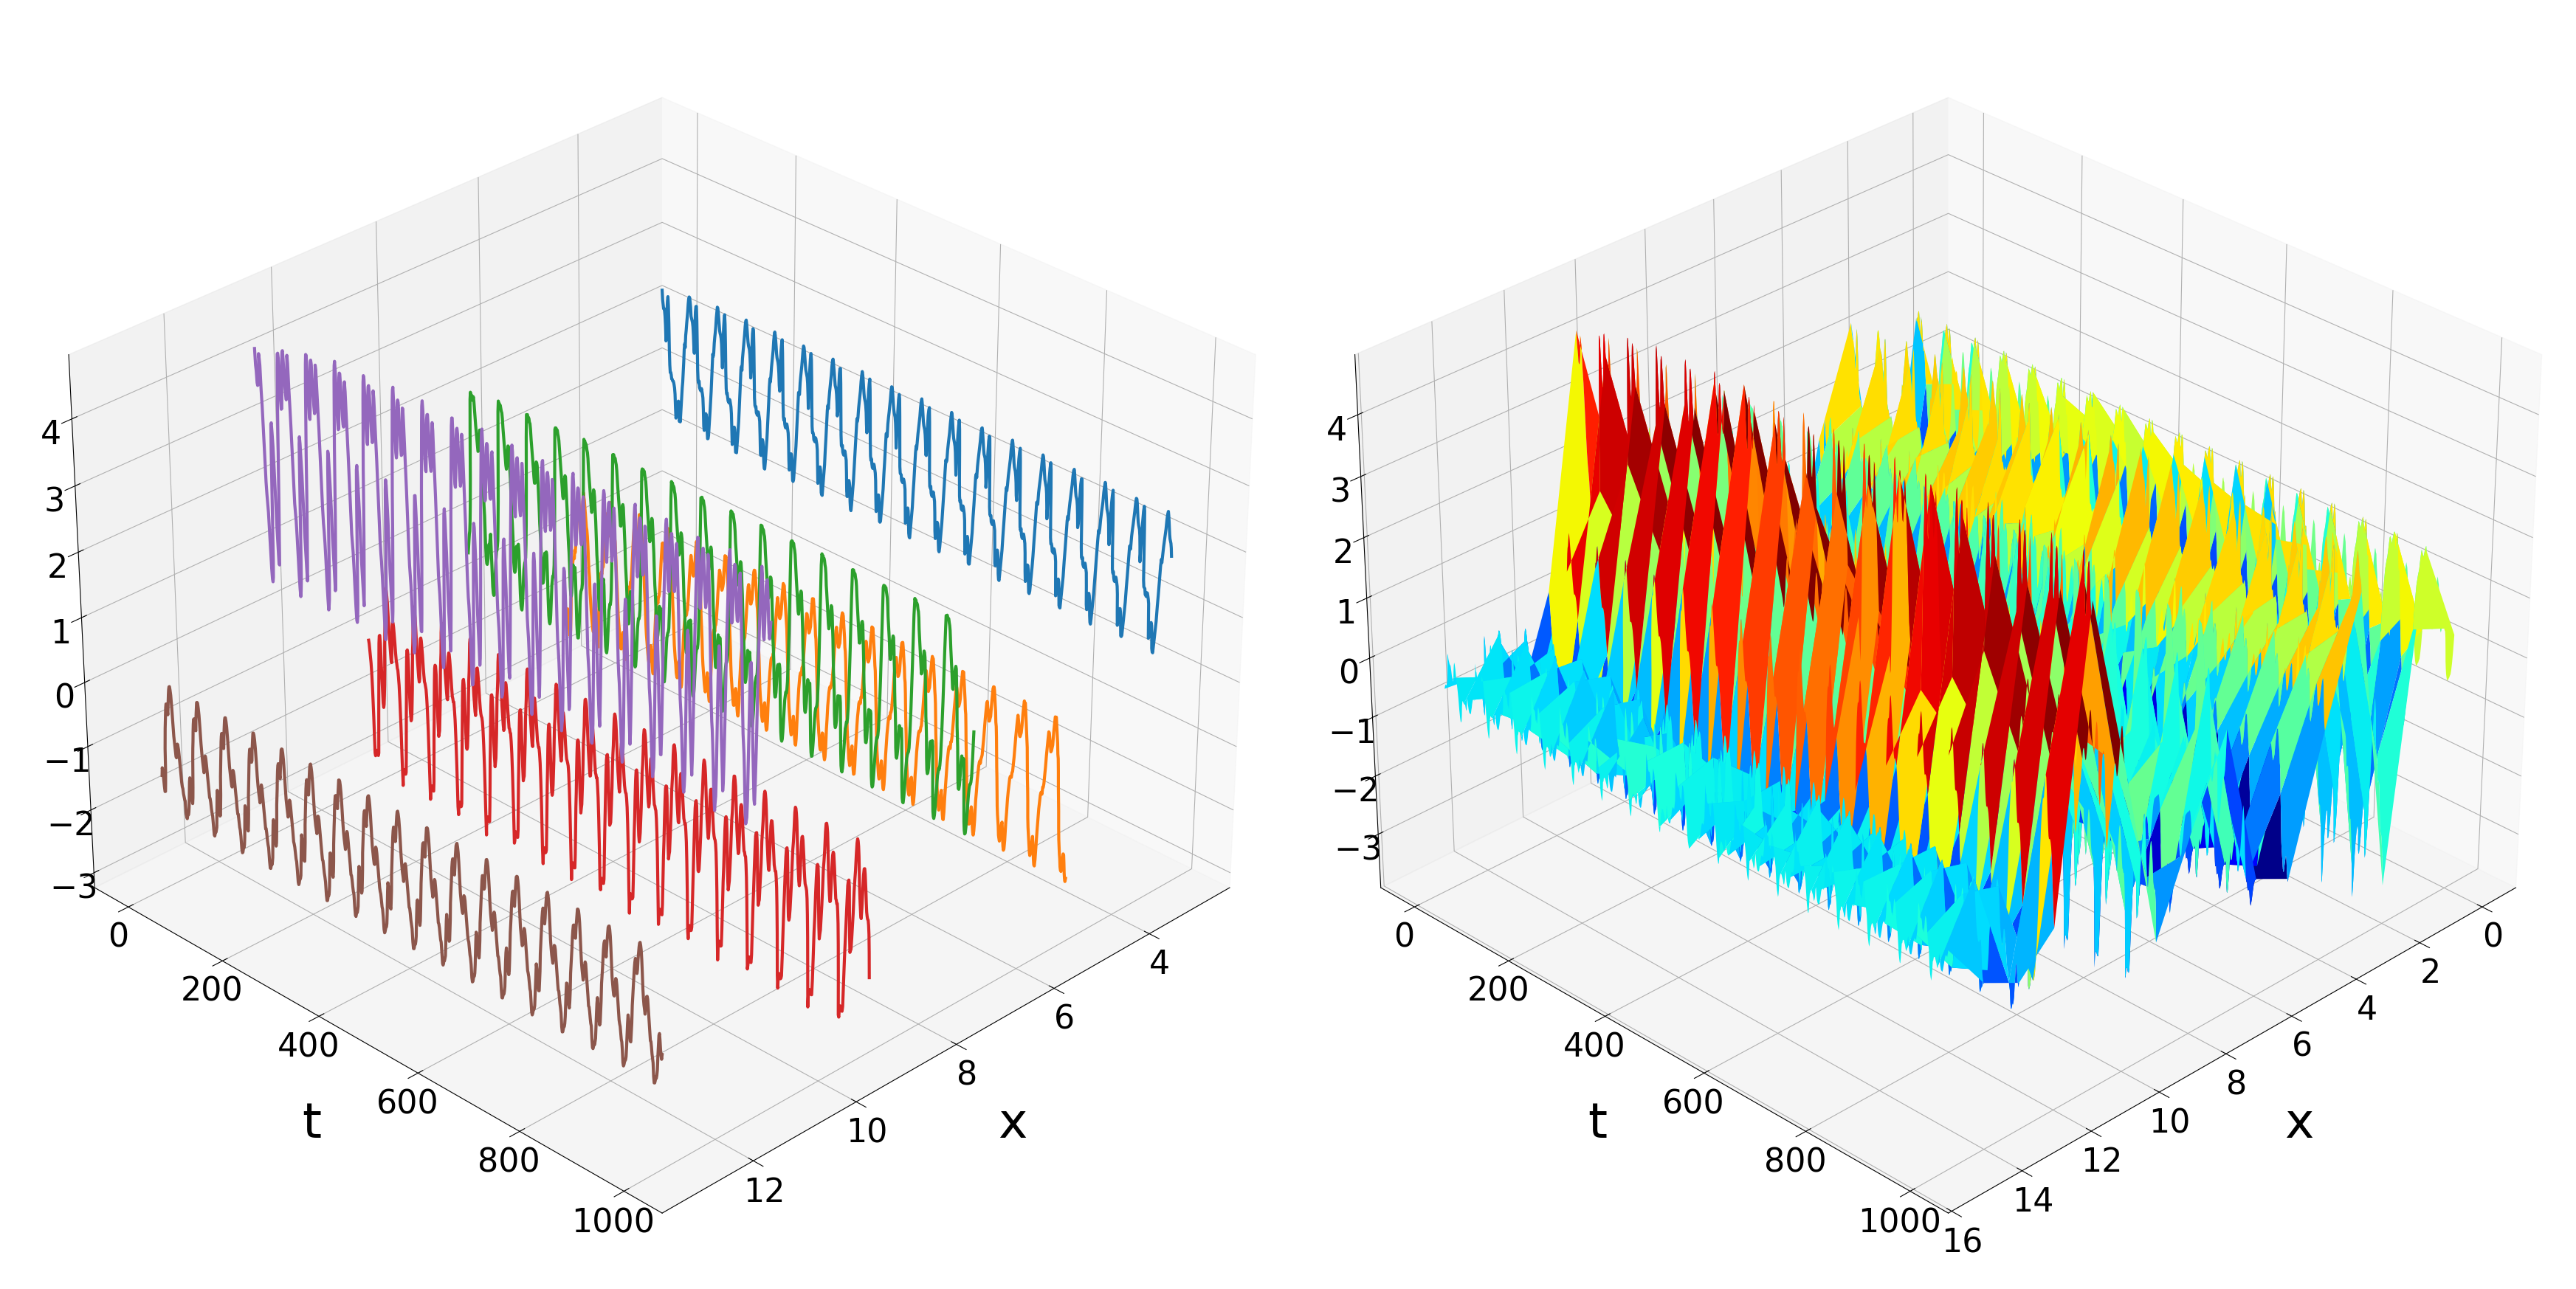

In [14]:
X, Y = np.meshgrid(np.arange(encoder_list.shape[1]), np.arange(encoder_list.shape[0]))

fig, axes = plt.subplots(1, 2, figsize=(35, 18), subplot_kw={'projection': '3d'})  # One row, two columns

# Select a few x indices for multiline plotting
x_indices = np.linspace(3, encoder_list.shape[1] - 3, num=6, dtype=int)  

# First subplot: Multi-line plot
ax1 = axes[0]
for x_idx in x_indices:
    ax1.plot(X[:, x_idx], Y[:, x_idx], encoder_list[:, x_idx], linewidth=3, label=f'x={x_idx}')

ax1.set_xlabel('x', fontsize=48, labelpad=40)
ax1.set_ylabel('t', fontsize=48, labelpad=40)
#ax1.set_zlabel('Vorticity', fontsize=30, labelpad=10)
ax1.tick_params(axis='both', which='major', labelsize=32)  # Affects x and y axes
ax1.tick_params(axis='z', which='major', labelsize=32)  # Explicitly affects z-axis
#ax1.zaxis.label.set_rotation(90)
ax1.zaxis.label.set_verticalalignment('bottom')
ax1.view_init(elev=30, azim=45)
#ax1.legend(fontsize=18, loc='upper right')
#ax1.set_title('Multi-line Plot', fontsize=26)

# Second subplot: Surface plot
ax2 = axes[1]
surf0 = ax2.plot_surface(X, Y, encoder_list, cmap='jet', edgecolor='none')
ax2.set_xlabel('x', fontsize=48, labelpad=40)
ax2.set_ylabel('t', fontsize=48, labelpad=40)
#ax2.set_zlabel('Vorticity', fontsize=24, labelpad=20)
ax2.tick_params(axis='both', which='major', labelsize=32)
ax2.zaxis.label.set_rotation(45)
ax2.zaxis.label.set_verticalalignment('bottom')
ax2.view_init(elev=30, azim=45)
#ax2.set_title('Surface Plot', fontsize=26)

# Adjust layout
fig.tight_layout()
plt.show()